### Here I will test out the data which was exportet to the experanto format

In [ ]:
import os
import torch
import torchvision
print("cwd: ", os.getcwd())
print("torch:", torch.__version__, "cuda:", torch.version.cuda)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())


torch: 2.5.1 cuda: 12.4
torchvision: 0.20.1
cuda available: True


In [ ]:
# additional imports for experanto
import matplotlib.pyplot as plt

from omegaconf import OmegaConf
from experanto.dataloaders import get_multisession_dataloader

In [ ]:
cfg = {
    "dataset": {
        "global_sampling_rate": None,
        "global_chunk_size": None,
        "add_behavior_as_channels": False,
        "replace_nans_with_means": False,
        "cache_data": False,
        "out_keys": [
            "screen",
            "responses",
            "image_id",
            "first_frame_idx"
        ],
        "normalize_timestamps": True,
        "modality_config": {
            "screen": {
                "keep_nans": False,
                "sampling_rate": 30,
                "chunk_size": 60,
                "valid_condition": {
                    "tier": "train",
                },
                "offset": 0,
                "sample_stride": 1,
                "include_blanks": False,
                "transforms": {
                    "normalization": "normalize",
                    "Resize": {
                        "_target_": "torchvision.transforms.v2.Resize",
                        "size": [144, 256],
                    },
                },
                "interpolation": {
                    "rescale": True,
                    "rescale_size": [144, 256],
                },
            },
            "responses": {
                "keep_nans": False,
                "sampling_rate": 8,
                "chunk_size": 16,
                "offset": 0.0,
                "transforms": {
                    "normalization": "standardize",
                },
                "interpolation": {
                    "interpolation_mode": "nearest_neighbor",
                },
                "filters": {
                    "nan_filter": {
                        "__target__": "experanto.filters.common_filters.nan_filter",
                        "__partial__": True,
                        "vicinity": 0.05,
                    },
                },
            },
        },
    },
    "dataloader": {
        "batch_size": 16,
        "shuffle": True,
        "num_workers": 4,
        "pin_memory": True,
        "drop_last": True,
        "prefetch_factor": 2,
    },
}


In [6]:
cfg = OmegaConf.create(cfg)

In [7]:
cfg.dataset.modality_config.screen.include_blanks = False
cfg.dataset.modality_config.screen.valid_condition = {"tier": "validation"}
cfg.dataloader.num_workers = 4

In [ ]:
paths = ["/mnt/vast-nhr/projects/bthesis_cidas_richter/benjamin/minimodel/internship/data_experanto/nat30k_L1_A5_022723_experanto"]
val_dl = get_multisession_dataloader(paths, cfg)

/user/benjamin.richter02/u23846/.conda/envs/mini-exp-venv2/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [9]:
dataset_name, batch = next(iter(val_dl))
print(
    f"dataset: {dataset_name}",
)
for k, v in batch.items():
    # print(f"modality: {k}, shape: {v.shape}")

    print("Modality: ", k)
    if hasattr(v, "shape"):
        print("Shape:", v.shape)
    elif isinstance(v, dict):
        print("Sub-dict keys:", list(v.keys()))
    else:
        print("Type:", type(v))
    print()

# video shape: batch, times, channels, height, width
# neuronal responses: batch, times, neurons

dataset: session_0
Modality:  responses
Shape: torch.Size([16, 16, 6636])

Modality:  screen
Shape: torch.Size([16, 1, 60, 144, 256])



KeyError: 'image_id'

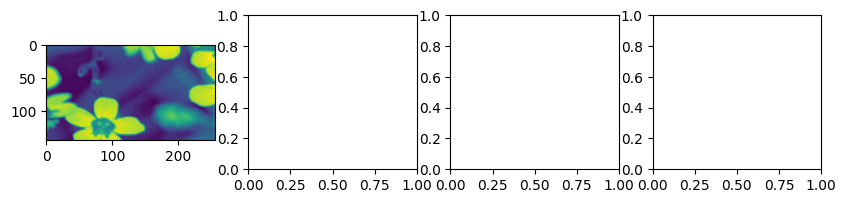

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2))
for i, ax in enumerate(axs.ravel()):
    ax.imshow(batch["screen"][i, 0, 0])  # video frames that the mouse sees
    title = str(batch["image_id"][i]) + "  | " + str(batch["first_frame_idx"][i])
    ax.set_title(title)
    ax.axis("off");

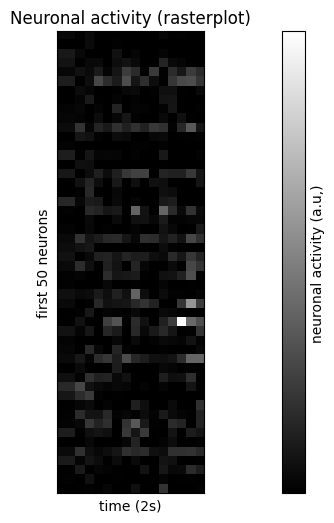

In [ ]:
n_neurons = 50

fig, axs = plt.subplots(1, 1, figsize=(20, 6))
c = axs.imshow(batch["responses"][0, :, :n_neurons].T, vmin=0, cmap="gray")
axs.set(
    ylabel=f"first {n_neurons} neurons",
    xlabel="time (2s)",
    xticks=[],
    yticks=[],
    title="Neuronal activity (rasterplot)",
)
ax = plt.colorbar(c)
ax.ax.set(yticks=[], ylabel="neuronal activity (a.u,)");